# 🛒 RFM Customer Segmentation Analysis

## E-commerce Customer Behavior Analysis Project

**Author:** Mohit Verma  
**Date:** May 2026  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Power BI  
**Dataset:** E-commerce transactions (28,000+ records, 2,500 customers)

---

## 📋 Project Overview

This project performs **RFM (Recency, Frequency, Monetary) Analysis** on e-commerce 
transaction data to segment customers based on their purchasing behavior.

### What is RFM Analysis?
- **Recency (R):** How recently did a customer make a purchase?
- **Frequency (F):** How often do they purchase?
- **Monetary (M):** How much do they spend?

### Business Goal
Identify high-value customer segments to:
1. Retain top customers (Champions)
2. Re-engage at-risk customers (Win-back campaigns)
3. Convert new customers into loyal buyers
4. Optimize marketing spend by segment

---

## Import Libraries and Load Data

- Load the e-commerce dataset
- View the first few rows to understand the structure

In [42]:
import pandas as pd
df = pd.read_csv('../RFM-Customer-Segmentation/data/ecommerce_data.csv')

In [44]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,Email,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,TotalAmount,PaymentMethod,OrderStatus,City,State,Country
0,ORD0107365,2023-01-02,CUST01347,Suresh Shah,customer1347@email.com,P6930,Wireless Earbuds,Electronics,SoundMax,1,1723.65,1723.65,UPI,Delivered,Hubli,Karnataka,India
1,ORD0100901,2023-01-02,CUST00156,Manish Kumar,customer156@email.com,P6426,Travel Guide,Books,ReadMore,3,643.09,1929.27,Debit Card,Delivered,Howrah,West Bengal,India
2,ORD0108662,2023-01-02,CUST01591,Anika Malhotra,customer1591@email.com,P1352,Dumbbells Set,Sports & Outdoors,FitLife,2,2168.09,4336.18,Credit Card,Returned,Kanpur,Uttar Pradesh,India
3,ORD0108908,2023-01-02,CUST01642,Anita Verma,customer1642@email.com,P7681,Poetry Collection,Books,ReadMore,1,437.42,437.42,Cash on Delivery,Delivered,Delhi,Delhi,India
4,ORD0106391,2023-01-02,CUST01174,Priya Iyer,customer1174@email.com,P9185,Fiction Novel,Books,BookWorld,1,463.09,463.09,Credit Card,Delivered,Kolkata,West Bengal,India


##  Explore the Data

- How many rows and columns do we have?
- What are the data types?
- Are there missing values?
- What are the basic statistics?


In [13]:
df.shape

(28231, 17)

### Check Column Information

- What information is available
- Which columns are numbers vs text vs dates
- If any columns need type conversion (especially dates!)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28231 entries, 0 to 28230
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        28231 non-null  object 
 1   OrderDate      28231 non-null  object 
 2   CustomerID     28231 non-null  object 
 3   CustomerName   28231 non-null  object 
 4   Email          28231 non-null  object 
 5   ProductID      28231 non-null  object 
 6   ProductName    28231 non-null  object 
 7   Category       28231 non-null  object 
 8   Brand          28231 non-null  object 
 9   Quantity       28231 non-null  int64  
 10  UnitPrice      28231 non-null  float64
 11  TotalAmount    28231 non-null  float64
 12  PaymentMethod  28231 non-null  object 
 13  OrderStatus    28231 non-null  object 
 14  City           28231 non-null  object 
 15  State          28231 non-null  object 
 16  Country        28231 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage: 

###  Convert OrderDate to Datetime Format

Currently, `OrderDate` is stored as text (`object`).  
We need to convert it to **datetime** format so we can:
- Calculate days between dates (for Recency)
- Filter by date ranges
- Extract year, month, day for trends

We'll use `pd.to_datetime()` to convert it.

In [23]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28231 entries, 0 to 28230
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        28231 non-null  object        
 1   OrderDate      28231 non-null  datetime64[ns]
 2   CustomerID     28231 non-null  object        
 3   CustomerName   28231 non-null  object        
 4   Email          28231 non-null  object        
 5   ProductID      28231 non-null  object        
 6   ProductName    28231 non-null  object        
 7   Category       28231 non-null  object        
 8   Brand          28231 non-null  object        
 9   Quantity       28231 non-null  int64         
 10  UnitPrice      28231 non-null  float64       
 11  TotalAmount    28231 non-null  float64       
 12  PaymentMethod  28231 non-null  object        
 13  OrderStatus    28231 non-null  object        
 14  City           28231 non-null  object        
 15  State          2823

###  Check Data Quality: Missing Values & Duplicates

 we must check:
- **Missing values:** Empty cells that could break calculations
- **Duplicate rows:** Same transactions appearing multiple times

If found, we need to decide:
- Delete them?
- Fill with default values?
- Investigate why they exist?

In [28]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
Email            0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
dtype: int64

###  Check for Duplicate Records

Duplicates can inflate our metrics and give wrong results.  
For example, if a customer's order is counted twice, their:
- Frequency would be wrong (counted as 2 orders instead of 1)
- Monetary value would be doubled

check for any duplicate rows in our data.

In [33]:
df.duplicated().sum()

0

###  Statistical Summary of Numerical Columns



In [36]:
df.describe()

,OrderDate,Quantity,UnitPrice,TotalAmount
count,28231,28231.000000,28231.000000,28231.000000
mean,2024-05-08 15:06:36.712833536,1.250540,5151.812463,6431.344191
min,2023-01-02 00:00:00,1.000000,100.300000,98.800000
25%,2023-11-07 00:00:00,1.000000,763.320000,863.170000
50%,2024-08-06 00:00:00,1.000000,1695.920000,1957.980000
75%,2024-11-19 00:00:00,1.000000,3794.835000,4428.360000
max,2024-12-31 00:00:00,3.000000,159480.210000,476952.750000
std,NaN,0.538129,14399.632335,20317.888205


## Set Reference Date for RFM Analysis

To calculate **Recency**, we need a reference point.

We'll use the **latest order date in our dataset + 1 day** as our reference date.

**Why?**
- Using today's actual date (2026) would make all customers look inactive
- Our data ends in 2024, so we treat that period as "now"
- Adding +1 day ensures recency is at least 1 (avoids zero values)

In [39]:
reference_date= df['OrderDate'].max()+pd.Timedelta(days=1)

print("Latest Order Date:",df['OrderDate'].max())
print("Reference Dtae( for Recency):",reference_date)

Latest Order Date: 2024-12-31 00:00:00
Reference Dtae( for Recency): 2025-01-01 00:00:00


## Calculate RFM Metrics

Now we'll calculate the three RFM metrics for each customer:

- **Recency:** Days since their last purchase
- **Frequency:** Total number of orders they placed  
- **Monetary:** Total amount they spent

We'll use **`groupby()`** to group all transactions by `CustomerID`,  
then aggregate the data to get one row per customer.

In [42]:
rfm = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (reference_date - x.max()).days,
    'OrderID': 'count',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,CUST00001,323,14,49861.78
1,CUST00002,410,2,1146.92
2,CUST00003,193,7,83337.32
3,CUST00004,377,3,14086.62
4,CUST00005,17,17,69011.61
5,CUST00006,8,27,86409.12
6,CUST00007,1,17,46589.05
7,CUST00008,523,1,7871.40
8,CUST00009,412,8,48762.62
9,CUST00010,443,10,30687.00


### Verify the RFM Calculation

Let's verify our calculation by checking:
- Total number of customers in the RFM table
- Statistical summary of R, F, M values
- This helps us understand the distribution before scoring

In [45]:
print("Total customers in RFM table:", len(rfm))
print()
print("RFM Statistics:")
rfm.describe()

Total customers in RFM table: 2500

RFM Statistics:


,Recency,Frequency,Monetary
count,2500.000000,2500.000000,2500.000000
mean,263.094400,11.292400,72625.311140
std,224.488782,11.369794,99768.588392
min,1.000000,1.000000,151.230000
25%,25.000000,4.000000,10910.992500
50%,242.000000,8.000000,33962.890000
75%,448.000000,15.000000,92986.437500
max,730.000000,69.000000,782711.710000


##  Score Each Customer (1-5 Scale)

Now we convert raw R, F, M values into scores from 1-5.

**Scoring Logic:**
- We use **quintiles** (5 equal groups) to assign scores
- **Recency:** Lower days = Higher score (recent = better)
- **Frequency:** Higher count = Higher score (frequent = better)
- **Monetary:** Higher amount = Higher score (high spend = better)

**Score Meaning:**
- Score 5 = Top 20% (Best)
- Score 4 = Next 20%
- Score 3 = Middle 20%
- Score 2 = Next 20%
- Score 1 = Bottom 20% (Worst)

In [48]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST00001,323,14,49861.78,3,4,4
1,CUST00002,410,2,1146.92,2,1,1
2,CUST00003,193,7,83337.32,3,3,4
3,CUST00004,377,3,14086.62,2,1,2
4,CUST00005,17,17,69011.61,4,4,4
5,CUST00006,8,27,86409.12,5,5,4
6,CUST00007,1,17,46589.05,5,4,3
7,CUST00008,523,1,7871.40,1,1,1
8,CUST00009,412,8,48762.62,2,3,3
9,CUST00010,443,10,30687.00,2,3,3


##  Combine R, F, M Scores

Now we'll create a combined **RFM_Score** by joining the three scores.

For example:
- R=5, F=5, M=5 → RFM_Score = "555" (Champion!)
- R=1, F=1, M=1 → RFM_Score = "111" (Lost)
- R=5, F=1, M=2 → RFM_Score = "512" (New Customer)

This single score tells us EVERYTHING about a customer's behavior.

In [51]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,323,14,49861.78,3,4,4,344
1,CUST00002,410,2,1146.92,2,1,1,211
2,CUST00003,193,7,83337.32,3,3,4,334
3,CUST00004,377,3,14086.62,2,1,2,212
4,CUST00005,17,17,69011.61,4,4,4,444
5,CUST00006,8,27,86409.12,5,5,4,554
6,CUST00007,1,17,46589.05,5,4,3,543
7,CUST00008,523,1,7871.40,1,1,1,111
8,CUST00009,412,8,48762.62,2,3,3,233
9,CUST00010,443,10,30687.00,2,3,3,233


## Create Customer Segments


### Segments We'll Create:
-  **Champions** - Best customers (high R, F, M)
-  **Loyal Customers** - Regular buyers
-  **At Risk** - High value but silent
-  **Churned Best Customers** - Frequent buyers gone silent
-  **New Customers** - Recent buyers, low frequency
-  **Need Attention** - Average customers
-  **Hibernating** - Low engagement
-  **Lost** - Long inactive



In [54]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f >= 4:
        return 'Churned Best Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 1 and f <= 2:
        return 'Lost'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Need Attention'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST00001,323,14,49861.78,3,4,4,344,Loyal Customers
1,CUST00002,410,2,1146.92,2,1,1,211,Hibernating
2,CUST00003,193,7,83337.32,3,3,4,334,Loyal Customers
3,CUST00004,377,3,14086.62,2,1,2,212,Hibernating
4,CUST00005,17,17,69011.61,4,4,4,444,Champions
5,CUST00006,8,27,86409.12,5,5,4,554,Champions
6,CUST00007,1,17,46589.05,5,4,3,543,Loyal Customers
7,CUST00008,523,1,7871.40,1,1,1,111,Lost
8,CUST00009,412,8,48762.62,2,3,3,233,Hibernating
9,CUST00010,443,10,30687.00,2,3,3,233,Hibernating


## Segment Distribution Analysis

 2,500 customers are distributed across segments.


- Which segments are largest?
- Where should we focus marketing efforts?
- How healthy is our customer base?

**Healthy distribution would have:**
- Many Champions and Loyal Customers (good!)
- Few Lost and Hibernating (bad to have many)
- Strong New Customer pipeline (growth!)

In [57]:
segment_counts = rfm['Segment'].value_counts()

print("Customer Distribution by Segment:")
print(segment_counts)
print()
print("Percentage Distribution:")
print((segment_counts / len(rfm) * 100).round(2))

Customer Distribution by Segment:
Segment
Champions                 671
Hibernating               645
Loyal Customers           476
Lost                      447
Need Attention            218
New Customers              28
Churned Best Customers      8
At Risk                     7
Name: count, dtype: int64

Percentage Distribution:
Segment
Champions                 26.84
Hibernating               25.80
Loyal Customers           19.04
Lost                      17.88
Need Attention             8.72
New Customers              1.12
Churned Best Customers     0.32
At Risk                    0.28
Name: count, dtype: float64


##  Revenue Analysis by Segment
**how much revenue each segment generates**.



**The famous 80/20 Rule (Pareto Principle):**
> 80% of revenue often comes from 20% of customers

In [60]:
segment_revenue = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Monetary': ['sum', 'mean']
}).round(2)

segment_revenue.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Customer_Value']

segment_revenue = segment_revenue.sort_values('Total_Revenue', ascending=False)

segment_revenue['Revenue_Percentage'] = (segment_revenue['Total_Revenue'] / segment_revenue['Total_Revenue'].sum() * 100).round(2)

segment_revenue

,Customer_Count,Total_Revenue,Avg_Customer_Value,Revenue_Percentage
Segment,,,,
Champions,671,1.177825e+08,175532.83,64.87
Loyal Customers,476,2.998031e+07,62983.85,16.51
Hibernating,645,1.695080e+07,26280.31,9.34
Lost,447,7.985061e+06,17863.67,4.40
Need Attention,218,6.579729e+06,30182.24,3.62
New Customers,28,1.221940e+06,43640.71,0.67
At Risk,7,8.031600e+05,114737.14,0.44
Churned Best Customers,8,2.597535e+05,32469.19,0.14


## 💾 Save RFM Data to CSV



In [63]:
rfm.to_csv('rfm_analysis_output.csv', index=False)

print("✅ RFM data saved successfully!")
print(f"Total customers saved: {len(rfm)}")
print(f"Columns: {list(rfm.columns)}")
print()
print("First 5 rows of saved data:")
rfm.head()

✅ RFM data saved successfully!
Total customers saved: 2500
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']

First 5 rows of saved data:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST00001,323,14,49861.78,3,4,4,344,Loyal Customers
1,CUST00002,410,2,1146.92,2,1,1,211,Hibernating
2,CUST00003,193,7,83337.32,3,3,4,334,Loyal Customers
3,CUST00004,377,3,14086.62,2,1,2,212,Hibernating
4,CUST00005,17,17,69011.61,4,4,4,444,Champions


##  Data Visualization



In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Visualization libraries loaded successfully!")
print("Ready to create beautiful charts!")

✅ Visualization libraries loaded successfully!
Ready to create beautiful charts!


###  Customer Segment Distribution (Bar Chart)


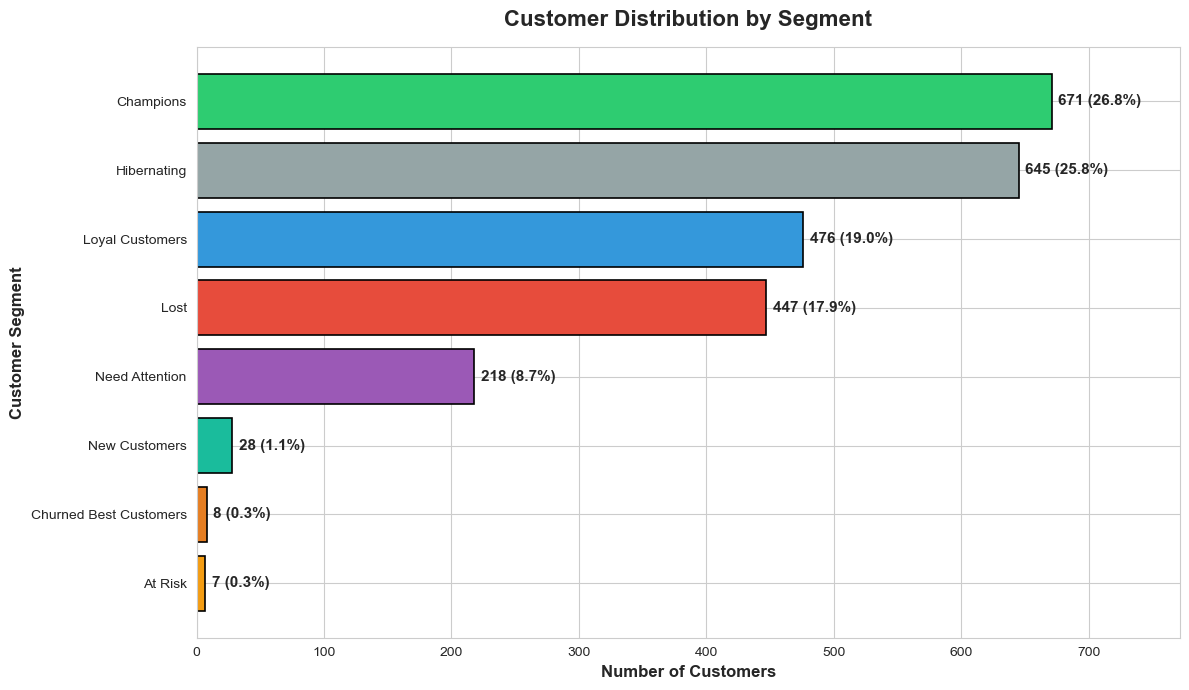

In [72]:
plt.figure(figsize=(12, 7))

segment_counts = rfm['Segment'].value_counts().sort_values(ascending=True)

colors_map = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'Need Attention': '#9b59b6',
    'New Customers': '#1abc9c',
    'At Risk': '#f39c12',
    'Churned Best Customers': '#e67e22',
    'Hibernating': '#95a5a6',
    'Lost': '#e74c3c'
}

bar_colors = [colors_map[seg] for seg in segment_counts.index]

bars = plt.barh(segment_counts.index, segment_counts.values, color=bar_colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)} ({width/len(rfm)*100:.1f}%)',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Number of Customers', fontsize=12, fontweight='bold')
plt.ylabel('Customer Segment', fontsize=12, fontweight='bold')
plt.title('Customer Distribution by Segment', fontsize=16, fontweight='bold', pad=15)

plt.xlim(0, max(segment_counts.values) * 1.15)

plt.tight_layout()
plt.show()

### Revenue by Segment(Bar Chart)



/var/folders/00/w2w6bgwn7fz26tqx6lhkl5480000gn/T/ipykernel_64374/2419612660.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


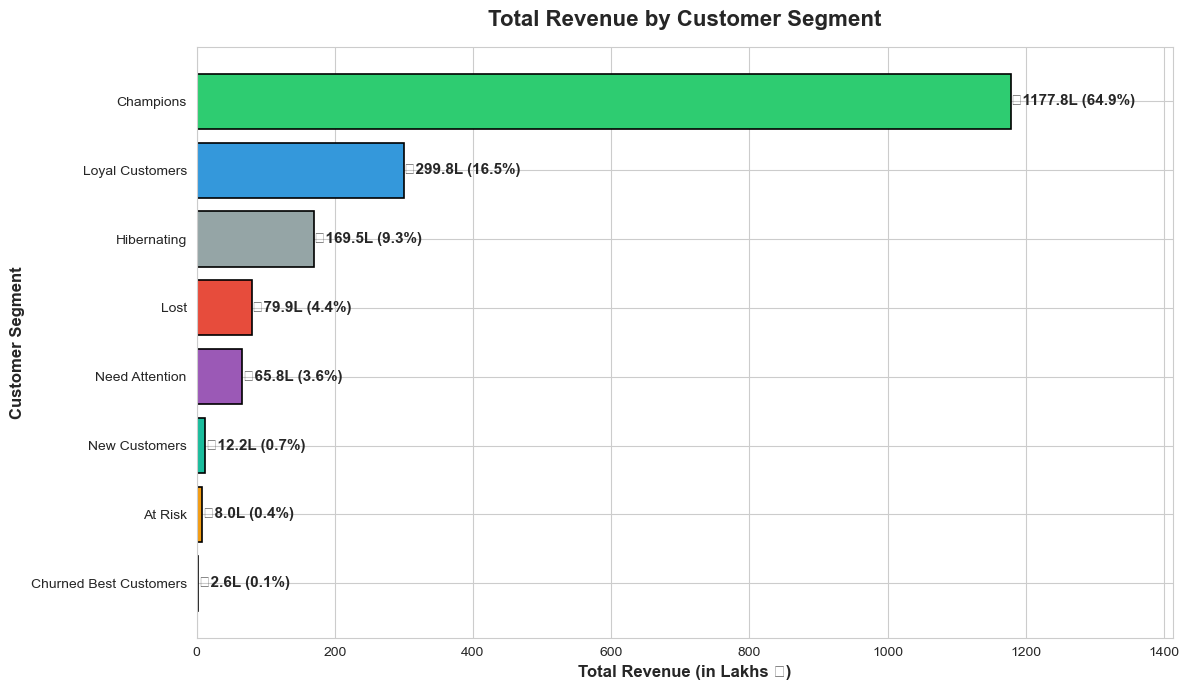

In [75]:
plt.figure(figsize=(12, 7))

revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)

revenue_in_lakhs = revenue_by_segment / 100000

bar_colors_revenue = [colors_map[seg] for seg in revenue_by_segment.index]

bars = plt.barh(revenue_in_lakhs.index, revenue_in_lakhs.values, color=bar_colors_revenue, edgecolor='black', linewidth=1.2)

total_revenue = revenue_by_segment.sum()
for bar, segment in zip(bars, revenue_by_segment.index):
    width = bar.get_width()
    revenue_pct = (revenue_by_segment[segment] / total_revenue) * 100
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'₹{width:.1f}L ({revenue_pct:.1f}%)',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Total Revenue (in Lakhs ₹)', fontsize=12, fontweight='bold')
plt.ylabel('Customer Segment', fontsize=12, fontweight='bold')
plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold', pad=15)

plt.xlim(0, max(revenue_in_lakhs.values) * 1.20)

plt.tight_layout()
plt.show()

###  Distribution of R, F, M Values(Histogram)



/var/folders/00/w2w6bgwn7fz26tqx6lhkl5480000gn/T/ipykernel_64374/3356765390.py:31: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


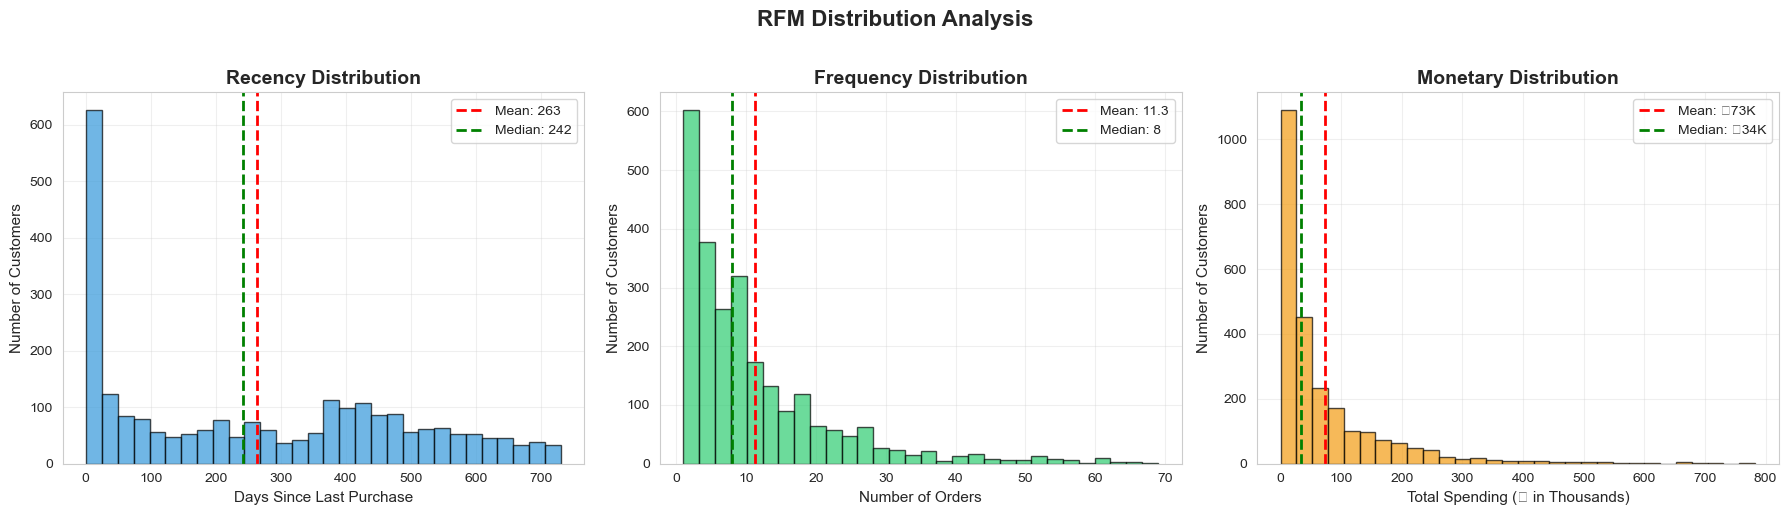

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recency'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rfm["Recency"].mean():.0f}')
axes[0].axvline(rfm['Recency'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {rfm["Recency"].median():.0f}')
axes[0].set_title('Recency Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(rfm['Frequency'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rfm["Frequency"].mean():.1f}')
axes[1].axvline(rfm['Frequency'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {rfm["Frequency"].median():.0f}')
axes[1].set_title('Frequency Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Orders', fontsize=11)
axes[1].set_ylabel('Number of Customers', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(rfm['Monetary']/1000, bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
axes[2].axvline(rfm['Monetary'].mean()/1000, color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{rfm["Monetary"].mean()/1000:.0f}K')
axes[2].axvline(rfm['Monetary'].median()/1000, color='green', linestyle='--', linewidth=2, label=f'Median: ₹{rfm["Monetary"].median()/1000:.0f}K')
axes[2].set_title('Monetary Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Spending (₹ in Thousands)', fontsize=11)
axes[2].set_ylabel('Number of Customers', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('RFM Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###  Average Customer Value by Segment



/var/folders/00/w2w6bgwn7fz26tqx6lhkl5480000gn/T/ipykernel_64374/636113176.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


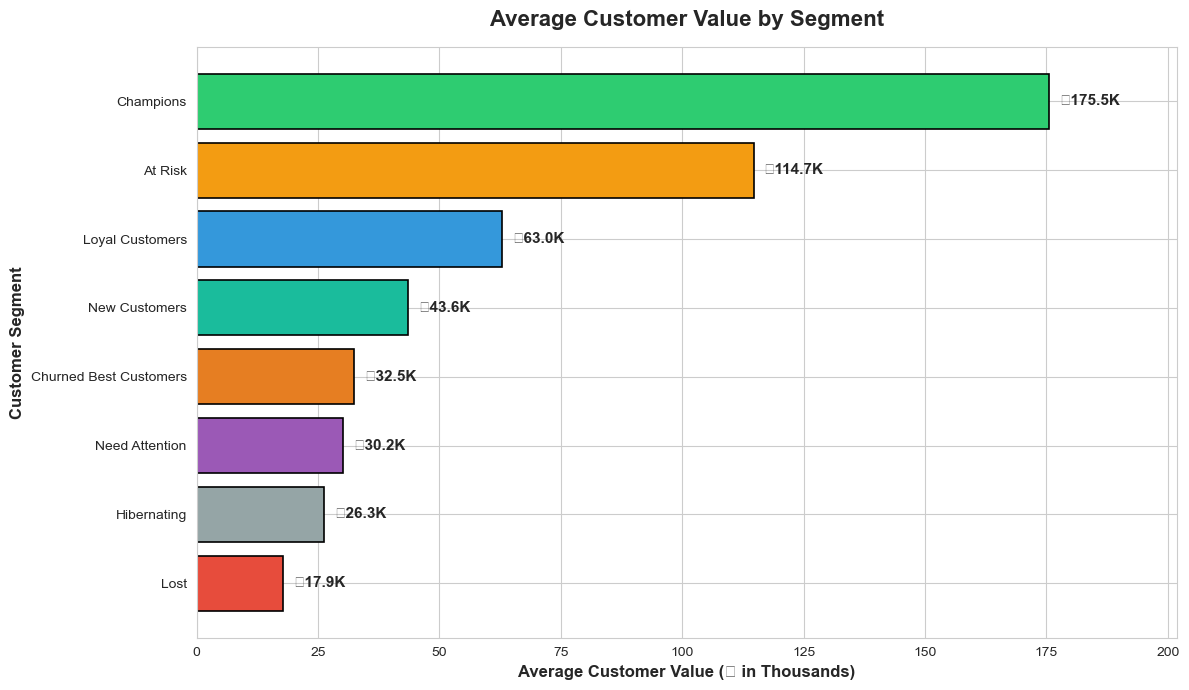

In [83]:
plt.figure(figsize=(12, 7))

avg_value = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)

avg_value_thousands = avg_value / 1000

bar_colors_avg = [colors_map[seg] for seg in avg_value.index]

bars = plt.barh(avg_value_thousands.index, avg_value_thousands.values, color=bar_colors_avg, edgecolor='black', linewidth=1.2)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, 
             f'₹{width:.1f}K',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Average Customer Value (₹ in Thousands)', fontsize=12, fontweight='bold')
plt.ylabel('Customer Segment', fontsize=12, fontweight='bold')
plt.title('Average Customer Value by Segment', fontsize=16, fontweight='bold', pad=15)

plt.xlim(0, max(avg_value_thousands.values) * 1.15)

plt.tight_layout()
plt.show()

##  Export Data for Power BI Dashboard



In [86]:
rfm_master = rfm.merge(
    df.groupby('CustomerID')[['City', 'State', 'Country']].first().reset_index(),
    on='CustomerID',
    how='left'
)

rfm_master.to_csv('rfm_master.csv', index=False)
print(f"✅ rfm_master.csv saved! ({len(rfm_master)} customers)")

segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['sum', 'mean']
}).round(2)

segment_summary.columns = ['Customer_Count', 'Avg_Recency', 'Avg_Frequency', 'Total_Revenue', 'Avg_Customer_Value']
segment_summary = segment_summary.reset_index()

segment_summary['Revenue_Percentage'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(2)

segment_summary.to_csv('segment_summary.csv', index=False)
print(f"✅ segment_summary.csv saved! ({len(segment_summary)} segments)")

df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)
monthly_trends = df.groupby('Month').agg({
    'OrderID': 'count',
    'TotalAmount': 'sum',
    'CustomerID': 'nunique'
}).reset_index()
monthly_trends.columns = ['Month', 'Total_Orders', 'Total_Revenue', 'Active_Customers']
monthly_trends['Avg_Order_Value'] = (monthly_trends['Total_Revenue'] / monthly_trends['Total_Orders']).round(2)

monthly_trends.to_csv('monthly_trends.csv', index=False)
print(f"✅ monthly_trends.csv saved! ({len(monthly_trends)} months)")

geographic_summary = rfm_master.groupby('State').agg({
    'CustomerID': 'count',
    'Monetary': ['sum', 'mean']
}).round(2)

geographic_summary.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Customer_Value']
geographic_summary = geographic_summary.reset_index()
geographic_summary = geographic_summary.sort_values('Total_Revenue', ascending=False)

geographic_summary.to_csv('geographic_summary.csv', index=False)
print(f"✅ geographic_summary.csv saved! ({len(geographic_summary)} states)")

print("\n" + "="*60)
print("🎉 ALL FILES EXPORTED SUCCESSFULLY!")
print("="*60)
print("\nFiles ready for Power BI:")
print("1. rfm_master.csv         - Customer-level RFM data")
print("2. segment_summary.csv    - Segment aggregations")
print("3. monthly_trends.csv     - Time-series data")
print("4. geographic_summary.csv - State-wise data")

✅ rfm_master.csv saved! (2500 customers)
✅ segment_summary.csv saved! (8 segments)
✅ monthly_trends.csv saved! (24 months)
✅ geographic_summary.csv saved! (12 states)

🎉 ALL FILES EXPORTED SUCCESSFULLY!

Files ready for Power BI:
1. rfm_master.csv         - Customer-level RFM data
2. segment_summary.csv    - Segment aggregations
3. monthly_trends.csv     - Time-series data
4. geographic_summary.csv - State-wise data
